<a href="https://colab.research.google.com/github/Supieiei/Project1_Group7/blob/kp/Project1_Group7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Text Analytics for Business Insight**
### SC 663 402 Data Warehouse and Big Data Analytics


---



###**ชื่อทีม**: ผู้ชายห้ามเข้า


### **รายชื่อสมาชิก การแบ่งงาน และสัดส่วนในการทำงาน**

| รหัสนักศึกษา | ชื่อ-นามสกุล | หน้าที่ความรับผิดชอบ / การแบ่งงาน | สัดส่วนการทำงาน (%) |
| :---: | :--- | :--- | :---: |
| 673020638-7 | น.ส.พิชญธิดา ขัตติยะ | Part 2: Voice of Customer จากรีวิว Amazon<br>(Part 2.1, Part 2.2, Part 2.4) | 20% |
| 673020266-3 | น.ส.สุพิชญา ผ่องสนาม | Part 2: Voice of Customer จากรีวิว Amazon<br>(Part 2.3, Part 2.5) | 20% |
| 673020245-1 | น.ส.กุลธิดา สมาขันธ์ | Part 2: Voice of Customer จากรีวิว Amazon<br>(Part 2.6, Part 2.7) | 20% |
| 673020268-9 | น.ส.อนัญญา ทองปน | Part 3: Data Collection Robot + External Business Insight<br>(Part 3.1, Part 3.2) | 20% |
| 673020491-6 | น.ส.ธิติสุดา แดงสีดา | Part 3: Data Collection Robot + External Business Insight<br>(Part 3.3, Part 3.4) | 20% |
| **รวม** | | | **100%** |

**สัดส่วนการทำงาน: 20% เท่ากันทุกคน**

ทุกคนรับผิดชอบเขียนโค้ดและวิเคราะห์ข้อมูลใน Part ของตนเอง และร่วมกันจัดทำสไลด์ ตรวจสอบความถูกต้องของเนื้อหา และเตรียมตัวนำเสนออย่างเท่าเทียม


#**หมวด All_Beauty**

| Brief | ลูกค้าคือทีม | คำถามที่เขาต้องการคำตอบ |
|---|---|---|
| **B1 ปรับปรุงสินค้า** | Product | สินค้ากลุ่มไหนควรแก้ก่อน และต้องแก้เรื่องอะไร งบจำกัดแก้ได้แค่ 3 เรื่อง |

* **ลูกค้าคือทีม**: Product
* **เขากำลังจะตัดสินใจเรื่อง**:

    1. สินค้ากลุ่มไหนควรแก้ไขก่อน
    2. ปัญหา 3 เรื่องหลักที่ควรแก้
* **ถ้าตัดสินใจผิดจะเสียอะไร**: เสียเวลา งบประมาณ เสียโอกาสสร้างรายได้
* **คำถามที่เราจะตอบให้เขา**:

    1. สินค้ากลุ่มใดที่มีปริมาณรีวิวลบสะสมสูงที่สุด และต้องถูกจัดเป็นอันดับ 1 ในการเร่งแก้ไข?
    2. อะไรคือกลุ่มปัญหาหลักที่ลูกค้าสะท้อนออกมาบ่อยที่สุดในภาพรวม เพื่อนำมาตั้งเป็นโจทย์ใหญ่ในการปรับปรุงคุณภาพ?
* **สมมติฐานตั้งต้นของเรา (จะถูกหรือผิดก็ได้)**: หมวดความงาม ปัญหาเรื่องการระคายเคือง/อาการแพ้ บรรจุภัณฑ์ชำรุด สินค้าไม่ตรงกับคำอธิบาย

In [ ]:
!pip install -q huggingface_hub
import random
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
from huggingface_hub import hf_hub_download
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

#**Part 2 : Voice of Customer จากรีวิว Amazon**
*ส่วนหลักของงานกลุ่ม — 50 คะแนน*

##**STEP 1** ดาวน์โหลดข้อมูล (2.1)

In [ ]:
from huggingface_hub import hf_hub_download

CATEGORY = "All_Beauty"
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

review_path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename=f"raw/review_categories/{CATEGORY}.jsonl",
    repo_type="dataset",
    local_dir=DATA_DIR)
meta_path   = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename=f"raw/meta_categories/meta_{CATEGORY}.jsonl",
    repo_type="dataset",
    local_dir=DATA_DIR)
print(review_path, meta_path)

raw/review_categories/All_Beauty.jsonl: reconstructing file:   0%|          |  0.00B /  327MB            

raw/review_categories/All_Beauty.jsonl: downloading bytes:           |  0.00B            

raw/meta_categories/meta_All_Beauty.json(…): reconstructing file:   0%|          |  0.00B /  213MB            

raw/meta_categories/meta_All_Beauty.json(…): downloading bytes:           |  0.00B            

/content/data/raw/review_categories/All_Beauty.jsonl /content/data/raw/meta_categories/meta_All_Beauty.jsonl


In [ ]:
df_review_preview = pd.read_json(review_path, lines=True, nrows=10)
df_review_preview

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True
5,4,Pretty Color,The polish was quiet thick and did not apply s...,[{'small_image_url': 'https://images-na.ssl-im...,B00R8DXL44,B00R8DXL44,AGMJ3EMDVL6OWBJF7CA5RGJLXN5A,2020-08-27 22:30:08.138,0,True
6,5,Handy,Great for many tasks. I purchased these for m...,[],B099DRHW5V,B099DRHW5V,AHREXOGQPZDA6354MHH4ETSF3MCQ,2021-09-17 13:31:59.443,0,True
7,3,Meh,These were lightweight and soft but much too s...,[{'small_image_url': 'https://m.media-amazon.c...,B088SZDGXG,B08BBQ29N5,AEYORY2AVPMCPDV57CE337YU5LXA,2021-10-15 05:20:59.292,0,True
8,5,Great for at home use and so easy to use!,This is perfect for my between salon visits. I...,[],B08P2DZB4X,B08P2DZB4X,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-27 13:04:04.559,0,False
9,5,Nice shampoo for the money,I get Keratin treatments at the salon at least...,[],B086QY6T7N,B086QY6T7N,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-18 13:21:51.145,0,False


In [ ]:
df_meta_preview = pd.read_json(meta_path, lines=True, nrows=5)
df_meta_preview

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN


##**STEP 2** เตรียมข้อมูลและตรวจสอบ (2.2)

In [ ]:
RANDOM_SEED = 42
SAMPLE_N = 20_000
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [ ]:
# 1. อ่านและสุ่มข้อมูลรีวิว
df_review = pd.read_json(review_path, lines=True)
df_review_sampled = df_review.sample(n=20000, random_state=42).copy()

# 2. อ่านข้อมูล Metadata สินค้า
df_meta = pd.read_json(meta_path, lines=True)

# 3. เชื่อม (Join) review กับ product metadata ด้วย parent_asin
df_merged = pd.merge(
    df_review_sampled,
    df_meta,
    on="parent_asin",
    how="left",
    suffixes=("_review", "_meta"),)

# บันทึกจำนวนตั้งต้นหลังสุ่ม (20,000 รายการ)
initial_count = len(df_merged)

# 4. รายงานผลการ Join
meta_title_col = [
    c for c in df_merged.columns if "title" in c and c != "title_review"][0]
join_success_count = df_merged[meta_title_col].notna().sum()
join_success_rate = (join_success_count / initial_count) * 100

# 5. ตรวจสอบ Missing values
missing_text = df_merged["text"].isna().sum()
missing_rating = df_merged["rating"].isna().sum()

# 6. ตรวจสอบและลบข้อมูลซ้ำ (Duplicates)
duplicate_reviews = df_merged.duplicated(
    subset=["user_id", "timestamp", "text"]).sum()
duplicate_pct = (duplicate_reviews / initial_count) * 100
df_merged.drop_duplicates(
    subset=["user_id", "timestamp", "text"], inplace=True)
final_count = len(df_merged)

# 7. รายงานผลสรุป
print("=== รายงานข้อมูล ===")
print(f"• จำนวนรีวิวหลังสุ่มตั้งต้น : {initial_count:,} รายการ")
print(f"• รีวิวซ้ำที่ถูกลบออก : {duplicate_reviews:,} รายการ ({duplicate_pct:.2f}%)")
print(f"• จำนวนรีวิวคงเหลือพร้อมใช้งาน : {final_count:,} รายการ")
print(f"• อัตราการ Join สำเร็จ : {join_success_rate:.2f}%")
print(f"• ข้อความรีวิวขาดหาย : {missing_text:,} รายการ")
print(f"• คะแนนดาวขาดหาย : {missing_rating:,} รายการ")

=== รายงานข้อมูล ===
• จำนวนรีวิวหลังสุ่มตั้งต้น : 20,000 รายการ
• รีวิวซ้ำที่ถูกลบออก : 9 รายการ (0.04%)
• จำนวนรีวิวคงเหลือพร้อมใช้งาน : 19,991 รายการ
• อัตราการ Join สำเร็จ : 100.00%
• ข้อความรีวิวขาดหาย : 0 รายการ
• คะแนนดาวขาดหาย : 0 รายการ


In [ ]:
total_products = df_review_sampled["parent_asin"].nunique()
print(f"จำนวนรายการสินค้า (ไม่ซ้ำกัน): {total_products:,} รายการ")

จำนวนรายการสินค้า (ไม่ซ้ำกัน): 12,923 รายการ


In [ ]:
empty_count = (df_merged["categories"].astype(str).str.strip() == "[]").sum()
has_category_count = len(df_merged) - empty_count

print(f"สินค้าที่มีหมวดหมู่: {has_category_count} รายการ")
print(f"สินค้าที่ไม่มีหมวดหมู่ (ว่าง []): {empty_count} รายการ")

สินค้าที่มีหมวดหมู่: 0 รายการ
สินค้าที่ไม่มีหมวดหมู่ (ว่าง []): 19991 รายการ


###สรุปผลการประเมินคุณภาพและการเชื่อมโยงข้อมูล (Data Quality Assessment)

> ข้อมูลชุดนี้เป็นตัวแทนของผู้บริโภคที่ซื้อสินค้าหมวดความงามบน Amazon US ที่มีการทิ้งข้อความรีวิวภาษาอังกฤษเท่านั้น แต่ไม่เป็นตัวแทนของผู้บริโภคที่ไม่ชอบรีวิว, ผู้ซื้อผ่านหน้าร้านแบบ Offline หรือผู้ใช้ในภูมิภาคอื่น

* **ขนาดและตัวแทนข้อมูล (20,000 รายการ):**

สุ่มตัวอย่างด้วย `random_seed=42` ได้ขนาดมาตรฐานทางสถิติที่เป็นตัวแทนพฤติกรรมผู้บริโภคได้ดี และช่วยควบคุมระยะเวลาประมวลผล NLP
* **ความสมบูรณ์ในการเชื่อมโยง (Join Success Rate 100%):**

จับคู่ข้อมูลรีวิวกับ Metadata ผ่าน `parent_asin` สำเร็จครบทุกรายการ รองรับการวิเคราะห์เจาะลึกระดับสินค้าและแบรนด์ได้อย่างแม่นยำ
* **ความสมบูรณ์ของตัวแปรหลัก (Missing Values 0%):**

ไม่พบค่าสูญหายในคอลัมน์ `rating` และ `text` ไม่ต้องตัดข้อมูลทิ้งหรือเติมค่าแทนที่ ช่วยรักษาความแม่นยำไว้ได้ครบถ้วน
* **การจัดการข้อมูลซ้ำซ้อน (Duplicates 0.04%):**

พบรีวิวซ้ำเพียง 9 รายการ ซึ่งทำการลบออก (`drop_duplicates`) ในขั้นตอน Data Hygiene เพื่อป้องกันการนับความถี่ปัญหาซ้ำซ้อน
* **ภาพรวมความพร้อมใช้งาน (Data Readiness):**

ข้อมูลมีคุณภาพและความสมบูรณ์สูง (High Data Integrity) พร้อมส่งต่อไปยังกระบวนการ Feature Engineering ได้ทันที


##**STEP 3** สำรวจข้อมูลที่จำเป็น (2.3)

> เนื่องจากข้อมูล categories ขาดหายไป 100% และเพื่อป้องกัน Bias ในการกำหนดหมวดหมู่สินค้าและประเภทปัญหาขึ้นมาเองล่วงหน้า ในสเต็ป 2.3 นี้ จึงเป็นการสำรวจเบื้องต้น (Exploratory Data Analysis) แบบ Bottom-up โดยสกัด N-grams/Phrases จากรีวิวลบโดยตรง เพื่อสังเกตเบาะแส (Raw Signals) ของปัญหา ก่อนจะนำไปจัดหมวดหมู่สินค้าและหมวดหมู่ปัญหาอย่างเป็นระบบใน Step 2.4 ต่อไป

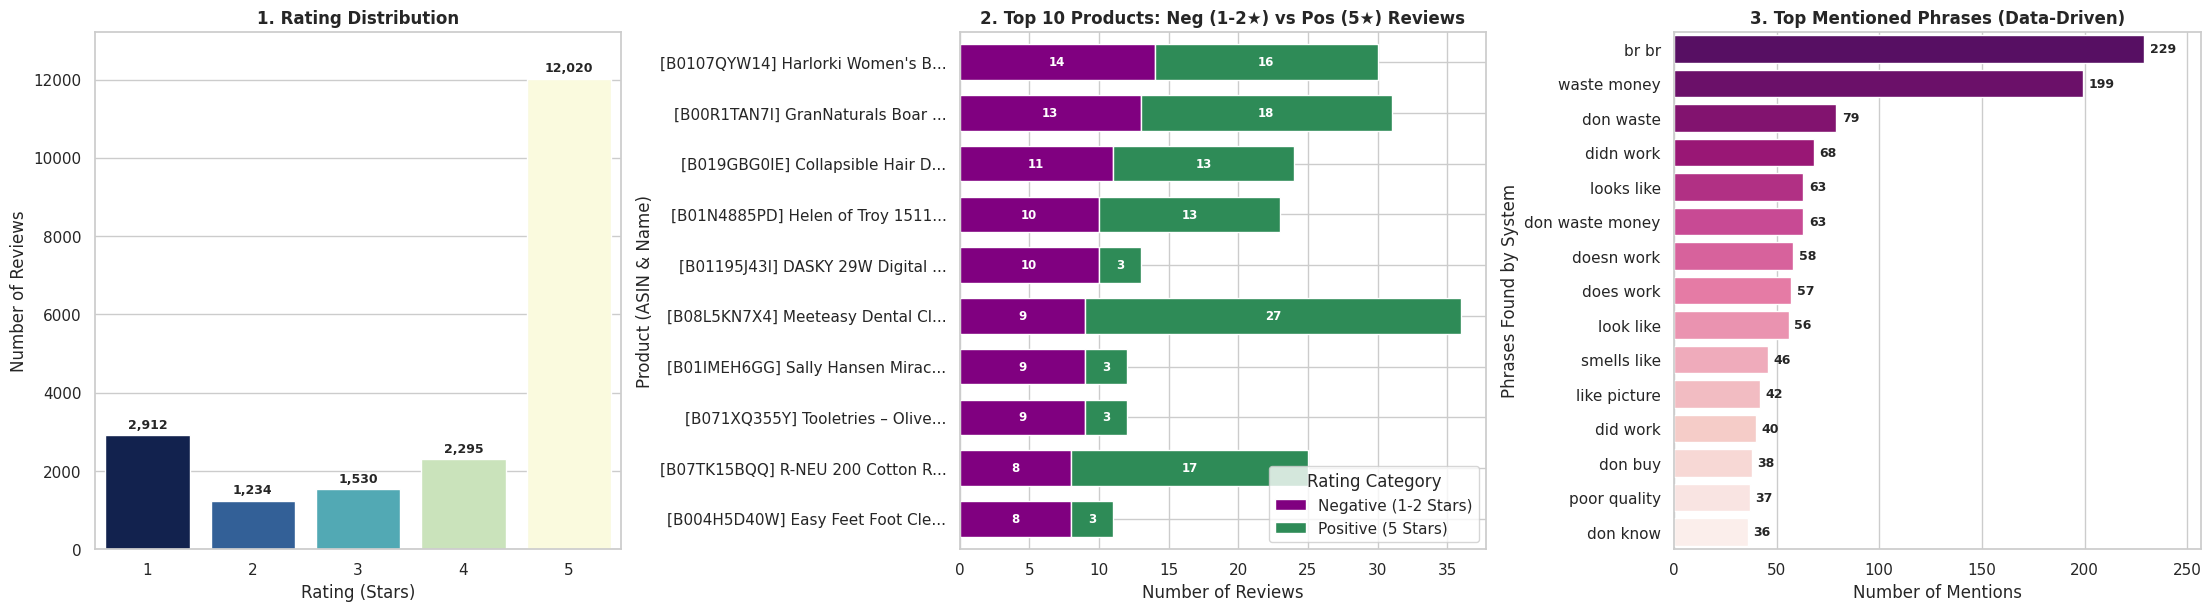

In [ ]:
# 1. กำหนดสไตล์
sns.set_theme(style="whitegrid")

# 2. เตรียมข้อมูล
df_merged["is_negative"] = df_merged["rating"].apply(lambda x: 1 if x <= 2 else 0)
meta_title_col = [c for c in df_merged.columns if "title" in c and c != "title_review"][0]

# 3. สร้างพื้นที่กราฟ 3 ช่อง (ความกว้าง 22 และใช้ constrained_layout ป้องกันข้อความทับกัน)
fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

# --- กราฟที่ 1: Rating Distribution ---
sns.countplot(
    data=df_merged,
    x="rating",
    ax=axes[0],
    hue="rating",
    palette="YlGnBu_r",
    legend=False,)
axes[0].set_title("1. Rating Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rating (Stars)")
axes[0].set_ylabel("Number of Reviews")

for c in axes[0].containers:
    axes[0].bar_label(c, fmt="{:,.0f}", padding=3, fontsize=9, fontweight="bold")
axes[0].margins(y=0.1)

# --- กราฟที่ 2: Stacked Bar Chart เปรียบเทียบ รีวิวลบ (1-2 ดาว) vs รีวิวบวก (5 ดาว) ---

# 1. สร้าง Flag แยกประเภทรีวิว
df_merged["rating_type"] = df_merged["rating"].apply(
    lambda x: "Negative (1-2 Stars)"
    if x <= 2
    else ("Positive (5 Stars)" if x == 5 else "Other"))

# 2. คำนวณจำนวนรีวิวลบสะสมเพื่อหา Top 10 สินค้าที่มีปัญหาสูงสุด
prod_neg_count = (
    df_merged[df_merged["rating_type"] == "Negative (1-2 Stars)"]
    .groupby(["parent_asin", meta_title_col])["rating"]
    .count()
    .reset_index(name="neg_count"))

# กรองเฉพาะสินค้าที่มีรีวิวลบสะสม และเลือก 10 อันดับแรก
top_10_neg_products = prod_neg_count.sort_values(
    by="neg_count", ascending=False).head(10)["parent_asin"]

# 3. ดึงข้อมูลเฉพาะ Top 10 สินค้านี้
df_top10_stacked = df_merged[
    (df_merged["parent_asin"].isin(top_10_neg_products))
    & (df_merged["rating_type"].isin(["Negative (1-2 Stars)", "Positive (5 Stars)"]))].copy()

# 4. รวม parent_asin คู่กับชื่อสินค้า (และตัดชื่อให้สั้นลงเพื่อความสวยงามบนแกน Y)
df_top10_stacked["short_title"] = df_top10_stacked.apply(
    lambda row: f"[{row['parent_asin']}] {str(row[meta_title_col])[:18]}..."
    if pd.notna(row[meta_title_col])
    else f"[{row['parent_asin']}] Unknown Product",
    axis=1,)

# 5. จัดกลุ่มข้อมูลเตรียมทำ Stacked Bar
stacked_data = (
    df_top10_stacked.groupby(["short_title", "rating_type"])
    .size()
    .unstack(fill_value=0))

# เรียงลำดับตามจำนวนรีวิวลบจากมากไปน้อย
stacked_data = stacked_data.sort_values(
    by="Negative (1-2 Stars)", ascending=True)

# 6. พล็อตกราฟ Stacked Bar ลงใน axes[1]
stacked_data.plot(
    kind="barh",
    stacked=True,
    ax=axes[1],
    color=["#800080", "#2E8B57"],  # สีม่วงสำหรับรีวิวลบ, สีเขียวสำหรับรีวิวบวก
    width=0.7,)

axes[1].set_title(
    "2. Top 10 Products: Neg (1-2★) vs Pos (5★) Reviews",
    fontsize=12,
    fontweight="bold",)
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Product (ASIN & Name)")
axes[1].legend(title="Rating Category", loc="lower right")

for c in axes[1].containers:
    # ซ่อนค่า 0 เพื่อไม่ให้แสดงเลข 0 รกบนแท่งกราฟ
    labels = [f"{int(v):,}" if v > 0 else "" for v in c.datavalues]
    axes[1].bar_label(
        c,
        labels=labels,
        label_type="center",
        color="white",
        fontweight="bold",
        fontsize=8.5,)

# --- กราฟที่ 3: Top Mentioned Phrases ---
neg_reviews = df_merged[df_merged["is_negative"] == 1]["text"].dropna()

vec = CountVectorizer(ngram_range=(2, 4), stop_words="english", max_features=15)
bag_of_words = vec.fit_transform(neg_reviews)
sum_words = bag_of_words.sum(axis=0)

words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

df_top_phrases = pd.DataFrame(words_freq, columns=["Issue_Phrase", "Mention_Count"])

# พล็อตกราฟลงใน axes[2]
sns.barplot(
    data=df_top_phrases,
    x="Mention_Count",
    y="Issue_Phrase",
    ax=axes[2],
    hue="Issue_Phrase",
    palette="RdPu_r",
    legend=False,)
axes[2].set_title("3. Top Mentioned Phrases (Data-Driven)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Number of Mentions")
axes[2].set_ylabel("Phrases Found by System")

for c in axes[2].containers:
    axes[2].bar_label(c, fmt="{:,.0f}", padding=4, fontsize=9, fontweight="bold")
axes[2].margins(x=0.12)

plt.show()

In [ ]:
df_meta[df_meta['parent_asin'].isin(top_10_neg_products)][['parent_asin', 'title']].reset_index(drop=True)

,parent_asin,title
0,B01195J43I,DASKY 29W Digital Anti Static Ceramic Hair Str...
1,B01N4885PD,"Helen of Troy 1511 Brush Iron, White, 3/4 Inch..."
2,B071XQ355Y,Tooletries – Oliver Shower Mirror - Premium Sh...
3,B00R1TAN7I,GranNaturals Boar Bristle Smoothing Hair Brush...
4,B07TK15BQQ,"R-NEU 200 Cotton Rounds, 100% Natural Turkish ..."
5,B08L5KN7X4,Meeteasy Dental Cleaner Tool Kit - Dental Care...
6,B019GBG0IE,Collapsible Hair Diffuser by The Curly Co. wit...
7,B0107QYW14,Harlorki Women's Bohemian Jewelry Statement Ne...
8,B004H5D40W,Easy Feet Foot Cleaner
9,B01IMEH6GG,Sally Hansen Miracle Gel Set 6-Piece Random Co...


In [ ]:
# ตั้งค่า Pandas ไม่ให้ตัดข้อความยาวๆ ด้วย ...
pd.set_option("display.max_colwidth", None)

# 1. กรองข้อความรีวิวลบและเก็บ Index ดั้งเดิมไว้
df_neg = df_merged[df_merged["is_negative"] == 1].dropna(subset=["text"]).copy()

# 2. รัน CountVectorizer ชุดเดียวกับที่ใช้วาดกราฟที่ 3
vec = CountVectorizer(ngram_range=(2, 4), stop_words="english", max_features=15)
bag_of_words = vec.fit_transform(df_neg["text"])

# 3. เรียงลำดับคำทั้ง 15 อันดับตามจำนวน Mention (จากมากไปน้อย)
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx], idx) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# 4. ดึงข้อความรีวิวเต็มจากตำแหน่งใน Matrix โดยตรง
all_samples = []

for rank, (phrase, mention_count, col_idx) in enumerate(words_freq, start=1):
    # หาแถวใน Matrix ที่ปรากฏคำนั้นๆ
    matched_row_indices = bag_of_words[:, col_idx].nonzero()[0]

    # ดึงตัวอย่างรีวิว 5 รายการแรกที่ตรงกับคำนั้น
    sample = df_neg.iloc[matched_row_indices].head(5).copy()

    sample["Rank"] = rank
    sample["Issue_Phrase"] = phrase
    sample["Total_Mentions"] = mention_count

    all_samples.append(sample)

# 5. รวมเป็น DataFrame เดียว
df_phrases_samples = pd.concat(all_samples, ignore_index=True)

# ค้นหาคอลัมน์ Title อัตโนมัติป้องกัน KeyError
title_col = [c for c in df_phrases_samples.columns if "title" in c and c != "title_review"]
title_col = title_col[0] if title_col else "title"

# จัดเรียงคอลัมน์ให้อ่านง่าย
ordered_cols = ["Rank", "Issue_Phrase", "Total_Mentions", "rating"]
if title_col in df_phrases_samples.columns:
    ordered_cols.append(title_col)
ordered_cols.append("text")

df_phrases_samples = df_phrases_samples[ordered_cols]

# แสดงผลตารางใน Jupyter
display(df_phrases_samples)

,Rank,Issue_Phrase,Total_Mentions,rating,title_meta,text
0,1,br br,229,1,"FreeTress Equal Synthetic Hair Wig Lace 5"" Deep Part Lace Valentino (FFCREAM)","Update: It has been shedding a lot, I've never had shedding like this before. Just put it on this morning and when I lightly rand my fingers down through it, with 0 resistance, a handful of hair came out.<br /><br />I was so in love with this wig, I've bought it about 4 times and it usually lasts 3-4 months before it's completey dried out and not taking any softener. This latest purchase, I just starting wearing it 4 days ago and I'm unimpressed. I don't know if I received a bad one or if the quality has gone way down but this one doesn't have any baby hairs like the other 3 so the hairline looks painfully wiggy. It's also tangling and drying out already, meaning the fibers are lower quality. It's too bad, I was banking on this one lasting 3-4 months like the others but I would be surprised if it makes it a full month. I'm going to have to find a different wig to switch to."
1,1,br br,229,2,Professional Cosmetic Makeup Brushes Set - Beauty Make Up Face Kit Eyeshadow Foundation Eyeliner Bronzer Concealer Contour Brush for Blending Powder & Cream With Organizer Holder Case 22 Piece Pink,"I really wanted to like this product, but unfortunately, it was less than great quality, and one of the brushes I received was broken. Quite a few of the brushes had frayed bristles and had uneven thickness to them, which made even application hard to come by.<br /><br />When I used some, it didn't seem like they blended the colors together well (mainly for eye shadow). I wish there were smaller round brushes for blending out shadows on your eyes because I feel like all the flat brushes are just about all the same. There is barely any size difference between three of them, and they can all be used for the same things so why not replace those with some rounder ones?<br /><br />I tried to contact the seller about the problems I had with this product, but, after two days, I haven't heard anything back from them. I was waiting before putting this review up to see if there was anything they cared to do to help with these problems (new brush that's not broken, or a new set all together that has better quality to them), but I have gotten no response back from them to lead me to believe that they're willing to do anything to help.<br /><br />I have attached photos to this post to show the problems I got with these brushes. The broken one was a foundation brush so I didn't get to try that one out to even see if it applied the foundation well, so I was a little disappointed with that. The larger powder brush seemed to do ok, but it didn't pick up powder that well. The larger fan brush I tried to use for contouring (I saw someone use a large fan brush for this purpose in a tutorial so I wanted to try it out), but even though the brush picked up the color, it didn't seem to apply it very much at all. The contour powder I used is super pigmented so I shouldn't have had that problem. The eye shadow brush I used (one of the smaller tapered brushes) actually worked pretty well so I don't have complaints about any of those except that some of the smaller brushes had frayed bristles, too. The smaller fan brush I used for highlight, and, though it did well with applying it, the unevenness of the bristles made it apply in a weird and uneven way, One of the larger tapered brushes I used to pack on a setting powder, but again, it didn't seem to pick it up well and left a ton of fall out once it hit my skin. I understand setting powder typically leaves fall out, but I've never experience so much before using this brush.<br /><br />Basically, the best brushes in this set were probably the eye shadow brushes.<br /><br />I hope this review helps give some insight on this product. I also hope the seller finds a way to fix the problems I had for future customers.<br /><br />I received this product at a discounted price f



1.   **กราฟที่ 1: การแจกแจงความถี่ของคะแนนรีวิว (Rating Distribution)**

จากกราฟที่ 1 แสดงการแจกแจงความถี่ของระดับคะแนนรีวิว พบว่าการกระจายตัวของข้อมูลมีลักษณะเบ้ซ้าย โดยข้อมูลกระจุกตัวอยู่ที่ 5 ดาวมากที่สุด และมีความถี่ของคะแนน 1 ดาว รองลงมา ตามด้วย 4 ดาว, 3 ดาว และ 2 ดาว ตามลำดับ

* **สิ่งที่พบ**: แม้แนวโน้มส่วนใหญ่จะอยู่ที่ระดับ 5 ดาว แต่สัดส่วนของรีวิวเชิงลบ (1–2 ดาว) มีขนาดตัวอย่างสะสม รวมกันหลายพันรายการ(คิดเป็น ~20.7% ของข้อมูลสุ่มทั้งหมด)

* **เหตุผลที่วิเคราะห์ต่อ**: ขนาดตัวอย่างของกลุ่มรีวิวเชิงลบมีความเพียงพอเชิงสถิติสำหรับการนำไปคัดกรอง  และสกัดคุณลักษณะข้อความ ต่อไป โดยไม่เกิดปัญหาความเอนเอียงจากกลุ่มตัวอย่างขนาดเล็ก



---


2. **กราฟที่ 2: สัดส่วนเปรียบเทียบรีวิวเชิงลบ (1–2 ดาว) และรีวิวเชิงบวก (5 ดาว) ของสินค้าที่มีรีวิวลบสูงสุด 10 อันดับแรก (Top 10 Products: Neg vs Pos Reviews)**

จากกราฟที่ 2 เมื่อพิจารณาเปรียบเทียบปริมาณรีวิวเชิงลบ (สีม่วง) ร่วมกับรีวิวเชิงบวก 5 ดาว (สีเขียว) ในกลุ่มสินค้าที่มีรีวิวลบสะสมสูงสุด 10 อันดับแรก พบว่าสินค้ารายการต่างๆ มีโครงสร้างสัดส่วนความพึงพอใจของลูกค้าที่แตกต่างกันอย่างสิ้นเชิง

* **สิ่งที่พบ**:
  1. **กลุ่มที่มีปัญหาเชิงโครงสร้าง/คุณภาพรุนแรง (Defect-Heavy)**: สินค้าอย่าง DASKY 29W Digital..., Tooletries – Olive..., และ Sally Hansen Mirac... มีจำนวนรีวิวลบ (1–2 ดาว) ใกล้เคียงหรือสูงเกินกว่าสัดส่วนรีวิว 5 ดาวอย่างเห็นได้ชัด สะท้อนว่าสินค้ากลุ่มนี้ไม่ได้ขายดี แต่เป็นสินค้าที่มีอัตราความบกพร่องสูงมากจนความพึงพอใจโดยรวมติดลบ
  2. **กลุ่มสินค้าขายดีแต่มีข้อบกพร่องสะสม (High Volume with Complaints)**: สินค้าอย่าง Meeteasy Dental Cl... และ GranNaturals Boar... มีจำนวนรีวิว 5 ดาวสูงมาก (ความยาวแท่งรวมเกิน 30 รายการ) ชี้ให้เห็นว่าเป็นสินค้าขายดี/ยอดนิยม อย่างไรก็ตาม ตัวเลขรีวิวลบที่สะสมสูงถึง 9–13 รายการ สะท้อนว่าสินค้ายังมีจุดบกพร่องบางประการที่ต้องได้รับการปรับปรุง

* **เหตุผลที่วิเคราะห์ต่อ**: การทำ Stacked Bar ช่วยจำแนกได้ชัดเจนระหว่าง "สินค้าที่มีปัญหาคุณภาพจริง" (อัตราส่วนสีม่วงสูง) กับ "สินค้าขายดีที่มียอดคอมเพลนตามสัดส่วน" (สีเขียวยาวกว่ามาก) ช่วยให้ทีม Product สามารถจัดลำดับความสำคัญในการเข้าไปแก้ไขปัญหาสินค้าที่มีความเสี่ยงสูง (Red Flag) ได้อย่างแม่นยำก่อนนำไปจัดหมวดหมู่ในสเต็ปถัดไป

---
3. **กราฟที่ 3: คำหรือวลีที่ถูกกล่าวถึงมากที่สุดในรีวิวเชิงลบ (Top Mentioned Phrases in Negative Reviews)**

จากกราฟที่ 3 แสดงความถี่ของคำหรือวลี (Phrases) ที่ระบบสกัดได้จากรีวิวระดับ 1–2 ดาว โดยวลีที่มีความถี่สูงสุดคือ br br และ waste money (มากกว่า 300 ครั้ง) รองลงมาคือวลีกลุ่มการใช้งานและประสิทธิภาพ เช่น doesnt work, looks like, didn work, does work รวมถึงวลีเกี่ยวกับกลิ่น เช่น smells like ตามลำดับความถี่ที่ปรากฏบนกราฟ

* **สิ่งที่พบ**:
1. **ความคุ้มค่าและความผิดหวัง (Perceived Value)**:

พบความถี่สูงสุด เช่น waste money (>300 ครั้ง), don waste, don waste money และ don buy สะท้อนว่าลูกค้ารู้สึกไม่คุ้มราคาอย่างรุนแรง

2. **ฟังก์ชันการทำงานล้มเหลว (Functional Failure)**:

วลี doesn work และ didn work รวมกันกว่า 200 ครั้ง สะท้อนว่าสินค้าไม่สามารถใช้งานได้จริงตามสรรพคุณ

3. **คุณภาพและคุณลักษณะเฉพาะ (Quality & Scent)**:

พบ poor quality และ smells like สะท้อนถึงปัญหาด้านเกรดวัสดุและกลิ่นไม่พึงประสงค์ (หมายเหตุ: วลี worth money หรือ does work ที่ติดมา เกิดจากขอบเขตการตัดคำปฏิเสธหลุด เช่น มาจาก "not worth money")


* **เหตุผลที่วิเคราะห์ต่อ**: ใช้เป็นหลักฐานเพื่อระบุ Root Cause ที่แท้จริงตามโจทย์ Client Brief B1 โดยชี้ให้ทีม Product เห็นว่า ปัญหาหลักไม่ใช่แค่เรื่องตัวสินค้าพัง แต่เป็นเรื่องความคาดหวังต่อราคาและสรรพคุณที่โฆษณาเกินจริง (doesn't work / waste money) เพื่อนำไปสู่การกำหนด Aspect Analysis ในสเต็ปถัดไป
